# Predicting Electric Vehicle Purchases

Kaggle Playground Series S6E9. Training and out-of-fold evaluation for a
binary tabular classification problem.

## Run summary

- 668,665 training rows; 286,571 test rows; ROC-AUC evaluation.
- Selected ensemble: 0.946314 OOF AUC and 0.94641 public leaderboard score.
- Same-day Top-10% cutoff: approximately 0.94650.
- No missing values, duplicate IDs, or measurable global train/test shift.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "reports").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
print(f"Project root detected: {ROOT.name}")

Project root detected: ev-purchase-kaggle


## 1. Validation setup

The target is the probability that a customer purchases an electric vehicle.
The competition metric is ROC-AUC. Comparable ablations use the same stratified
five-fold split with seed 42; the strongest pipeline is also refit with 10
folds under two seeds, plus a shallower 20-fold configuration. Target encoding
is learned only from the training portion of each fold, so validation labels
never enter their own features.

Model and blend selection use out-of-fold predictions. The public leaderboard
score is recorded only for the submitted artifact.

## 2. Data integrity and distribution shift

In [2]:
quality = json.loads((ROOT / "reports/data_quality.json").read_text())
pd.Series(quality, name="value").to_frame()

,value
train_rows,668665
test_rows,286571
train_columns,15
test_columns,14
positive_rate,0.174645
train_missing_cells,0
test_missing_cells,0
duplicate_train_ids,0
duplicate_test_ids,0
sample_ids_match_test,True


An adversarial classifier distinguishing train from test produced AUC 0.50035.

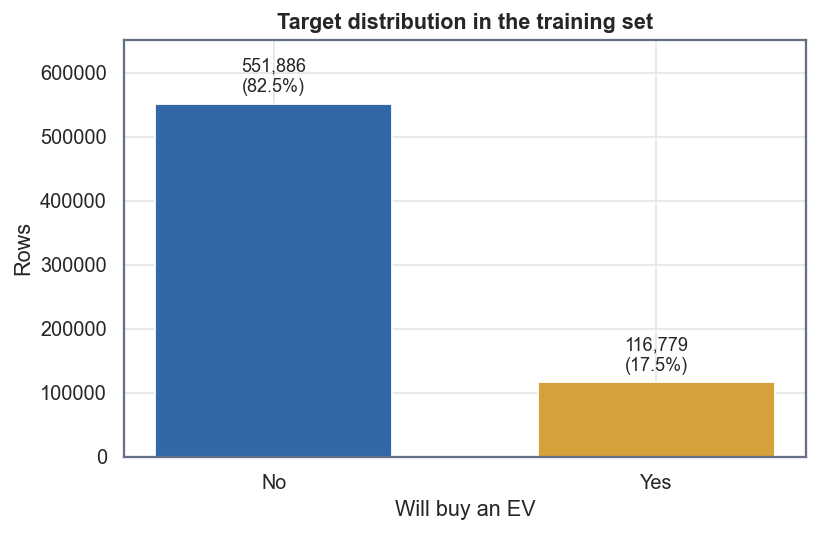

In [3]:
display(Image(filename=str(ROOT / "reports/figures/target_distribution.png"), width=700))

## 3. Signal exploration

In [4]:
univariate = pd.read_csv(ROOT / "reports/univariate_auc.csv")
univariate.head(10)

,feature,univariate_auc
0,Environmental_Concern_Level,0.843521
1,Subsidy_Available,0.717512
2,Annual_Income_USD,0.670367
3,Home_Charging_Possible,0.550204
4,Range_Anxiety_Level,0.544743
5,Daily_Commute_km,0.533757
6,City_Type,0.522133
7,Charging_Stations_Near_Home,0.515886
8,Charging_Stations_Near_Work,0.510620
9,Current_Car_Type,0.509436


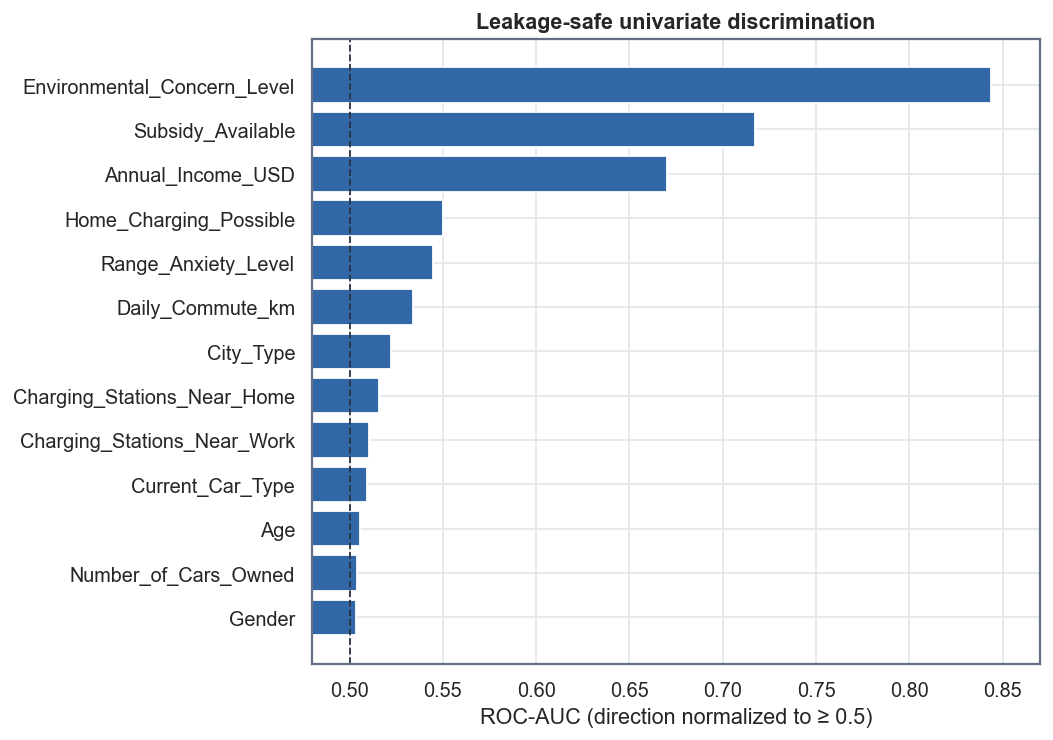

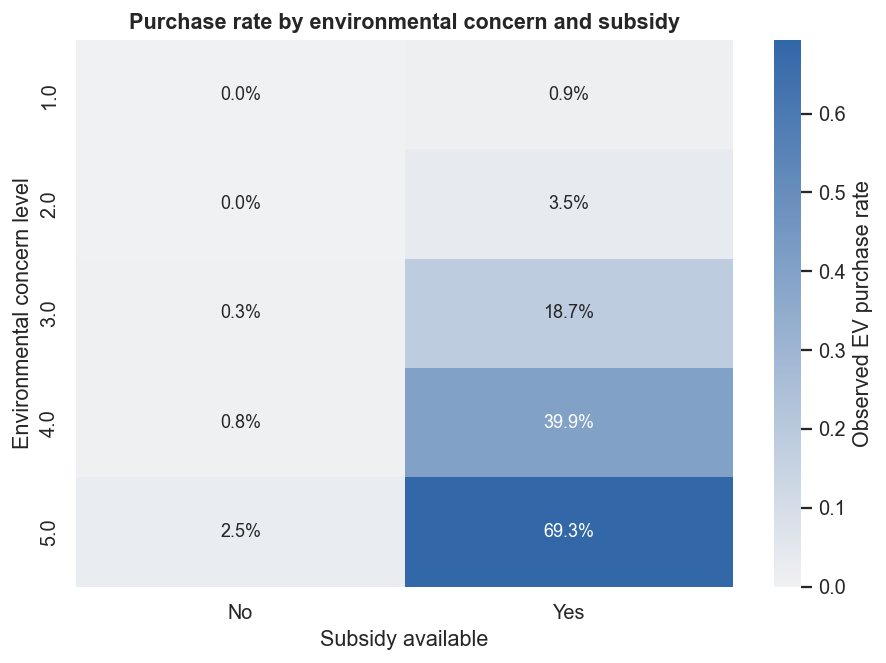

In [5]:
display(Image(filename=str(ROOT / "reports/figures/univariate_auc.png"), width=760))
display(Image(filename=str(ROOT / "reports/figures/concern_subsidy_heatmap.png"), width=720))

Environmental concern is the strongest standalone signal. Subsidy availability
and income are also important, while the heatmap shows a clear nonlinear
concern–subsidy interaction. These patterns favor boosted trees over a purely
additive linear model.

## 4. Experiments and fold-safe features

In [6]:
metrics = pd.DataFrame(json.loads((ROOT / "reports/model_metrics.json").read_text()))
metrics[["experiment", "model_kind", "feature_variant", "fold_target_encoding",
         "oof_auc", "fold_auc_mean", "fold_auc_std", "runtime_seconds"]].sort_values(
    "oof_auc", ascending=False
).reset_index(drop=True)

,experiment,model_kind,feature_variant,fold_target_encoding,oof_auc,fold_auc_mean,fold_auc_std,runtime_seconds
0,triple_lgbm_20fold_shallow,lgbm,digits_frequency_original_triple_te,True,0.946186,0.946197,0.001258,"2,345.536460"
1,triple_lgbm_10fold,lgbm,digits_frequency_original_triple_te,True,0.946184,0.946192,0.000812,535.842371
2,triple_lgbm_10fold_seed137,lgbm,digits_frequency_original_triple_te,True,0.946155,0.946164,0.000703,503.515784
3,triple_lgbm,lgbm,digits_frequency_original_triple_te,True,0.946057,0.946062,0.000690,245.716090
4,advanced_lgbm,lgbm,triple_plus_multiscale_crosses,True,0.945971,0.945978,0.000676,338.968038
5,xgb_digits,xgb,digits,False,0.944006,0.944012,0.000705,208.019426
6,enhanced_lgbm,lgbm,enhanced,False,0.943221,0.943231,0.000798,112.675786
7,baseline_lgbm,lgbm,base,False,0.942159,0.942169,0.000829,80.355121
8,catboost_diverse,catboost,base,False,0.941949,0.941956,0.000853,225.140652
9,xgb_digits_te,xgb,digits,True,0.901997,0.916376,0.005240,17.161223


The enhanced LightGBM adds global frequency features. XGBoost receives
digit-oriented numeric features. The strongest LightGBM adds source-data means
and cross-fitted target encodings at three smoothing levels. The leave-one-out
target-encoding variant is retained in the table because it reduced OOF AUC.

In [7]:
ensemble = json.loads((ROOT / "reports/ensemble_metrics.json").read_text())
summary = pd.Series({
    "blend_type": ensemble["blend_type"],
    "blend_oof_auc": ensemble["blend_oof_auc"],
    "fold_mean": ensemble["fold_mean"],
    "fold_std": ensemble["fold_std"],
    "folds_improved_vs_best_single": ensemble["folds_improved_vs_best_single"],
    "weights": {k: v for k, v in ensemble["weights"].items() if v > 0},
}, name="selected blend")
summary.to_frame()

,selected blend
blend_type,rank
blend_oof_auc,0.946314
fold_mean,0.946317
fold_std,0.000664
folds_improved_vs_best_single,5
weights,"{'triple_lgbm_20fold_shallow': 0.25, 'triple_l..."


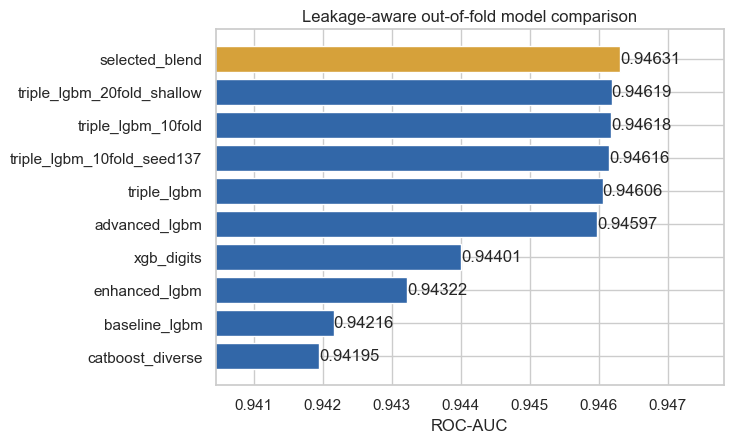

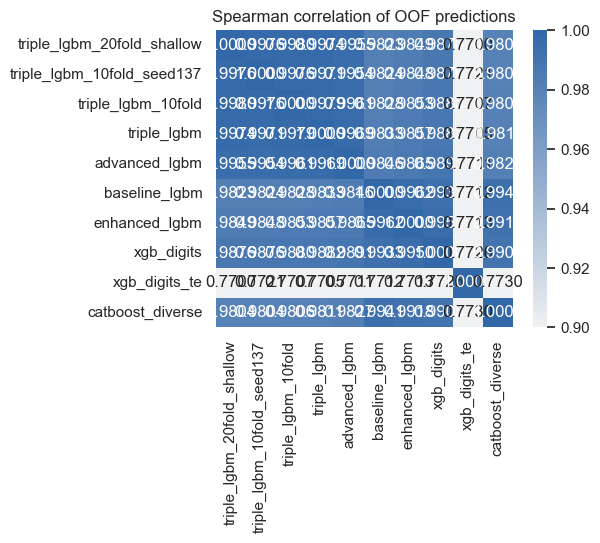

In [8]:
display(Image(filename=str(ROOT / "reports/figures/model_comparison.png"), width=760))
display(Image(filename=str(ROOT / "reports/figures/prediction_correlation.png"), width=680))

The final rank average combines two 10-fold splits and a shallower 20-fold fit
with three additional model views. The candidate set uses coarse, fixed weight
combinations. The chosen blend improved the pooled score and all five fixed
audit groups. These groups reuse OOF rows and are not independent replications.

## 5. Interpretation and submission checks

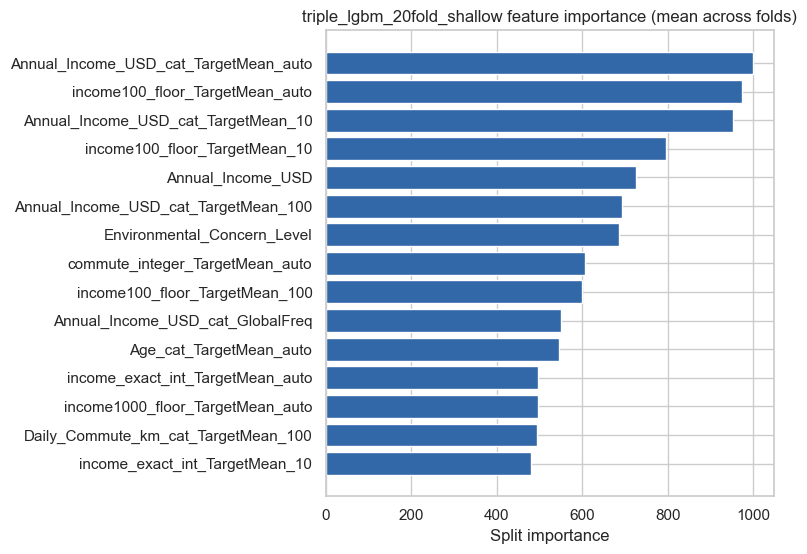

,0
file,submission_best.csv
local_oof_auc,0.946314
blend_type,rank
weights,"{""advanced_lgbm"": 0.11250000000000002, ""baseli..."
sha256,616a1d0dedfb6c72b5dbd8cdda4926960cb9cbce0f6f3f...
kaggle_uploaded,True
public_score,0.946410
submission_id,NaN


In [9]:
display(Image(filename=str(ROOT / "reports/figures/feature_importance.png"), width=760))

manifest = pd.read_csv(ROOT / "submissions/submission_manifest.csv")
manifest.T

In [10]:
submission = pd.read_csv(ROOT / "submissions/submission_best.csv")
pd.Series({
    "rows": len(submission),
    "unique_ids": submission["id"].nunique(),
    "min_probability": submission["Will_Buy_EV"].min(),
    "max_probability": submission["Will_Buy_EV"].max(),
    "missing_values": int(submission.isna().sum().sum()),
}, name="submission audit").to_frame()

,submission audit
rows,"286,571.000000"
unique_ids,"286,571.000000"
min_probability,0.000013
max_probability,0.999956
missing_values,0.000000


## 6. Selected configuration

Nested target encoding and source-data lookup features produced the largest
single-model gain. Repeated cross-validation and rank averaging added a smaller
increment. The saved manifest links the final prediction checksum to its Kaggle
score. Rank-averaged outputs are not calibrated probabilities, and the data is
synthetic.

## 7. Subgroup diagnostics and external score

The subgroup table describes OOF discrimination within each population slice.
Different case mixes make subgroup AUCs imperfectly comparable; this is not a
fairness certification. Rank scores have mean 0.5 by construction and are not
calibrated purchase probabilities.

Kaggle receipts are matched by SHA-256, keeping each observed external score
attached to the exact submitted artifact.

In [11]:
display(pd.read_csv(ROOT / "reports/subgroup_metrics.csv"))
display(pd.DataFrame(json.loads((ROOT / "reports/submission_receipts.json").read_text())))

,dimension,group,rows,positive_rows,positive_rate,oof_auc
0,City_Type,Rural,123983,23977,0.193389,0.941223
1,City_Type,Suburban,255377,46207,0.180936,0.945809
2,City_Type,Urban,289305,46595,0.161058,0.948751
3,Gender,Female,295427,52480,0.177641,0.946128
4,Gender,Male,367954,63381,0.172253,0.946534
5,Gender,Other,5284,918,0.173732,0.940815
6,Subsidy_Available,No,248756,1432,0.005757,0.884724
7,Subsidy_Available,Yes,419909,115347,0.274695,0.911647
8,Income_quintile,"(107798.0, 188549.0]",133724,41874,0.313138,0.939612
9,Income_quintile,"(29999.999, 62671.0]",133803,8634,0.064528,0.938558


,version,uploaded_filename,sha256,local_oof_auc,public_score,status,verified_on,verification
0,original_v1,submission_best.csv,94a2862a98d7ee83424bbbbcd1d2951fc6a19b8ff0bdb5...,0.946072,0.946270,Complete,2026-09-27,Signed-in Kaggle Submissions page
1,original_v2,submission_best_original.csv,5e05adabb6b998b39f88b38854da88fbf91b25bdfb4bde...,0.946252,0.946390,Complete,2026-09-27,Signed-in Kaggle Submissions page; matching SH...
2,original_v3,submission_original_v3.csv,d28a142ed23244db2ff8d3a8e97b3d4b71a397160b5827...,0.946298,0.946400,Complete,2026-09-27,Signed-in Kaggle Submissions page; matching SH...
3,original_v4,submission_original_v4.csv,616a1d0dedfb6c72b5dbd8cdda4926960cb9cbce0f6f3f...,0.946314,0.946410,Complete,2026-09-27,Signed-in Kaggle Submissions and Leaderboard p...
